Hands On Pertemuan 10

*   Nama : Samuel Binsar Aditya Simamora
*   NIM : 240401010275
*   Kelas : IF405





Langkah 1 Muat dan eksplorasi Data

In [6]:
import pandas as pd
df= pd.read_csv("telco_churn.csv")
print("ukuran dataset",df.shape)
print("\nTipe Data:")
print(df.dtypes)
print("\nProporsi Kelas Churn:")
print(df["Churn"].value_counts(normalize=True))

ukuran dataset (7043, 21)

Tipe Data:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Proporsi Kelas Churn:
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


Langkah 2 Preprocessing

In [7]:
from sklearn.model_selection import train_test_split

# TODO: Pisahkan X (fitur) dan y (target = Churn)
X = df.drop("Churn", axis=1)
y = df["Churn"]
# TODO: Encoding fitur kategorikal menggunakan pd.get_dummies
X = pd.get_dummies(X, drop_first=True)

# Bagi data menjadi latih/uji secara stratified
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print("\nData Latih:", X_tr.shape)
print("Data Uji:", X_te.shape)
print("Label Latih:", y_tr.shape)
print("Label Uji:", y_te.shape)




Data Latih: (5634, 13601)
Data Uji: (1409, 13601)
Label Latih: (5634,)
Label Uji: (1409,)


Langkah 3 : Latih Model

In [8]:

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42)
rf.fit(X_tr, y_tr)


RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

Langkah 4 : Evaluasi


--- Evaluasi Model ---
Classification Report:
               precision    recall  f1-score   support

          No       0.84      0.90      0.87      1035
         Yes       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC Score: 0.8337260068717869

Confusion Matrix (Angka):
[[928 107]
 [178 196]]


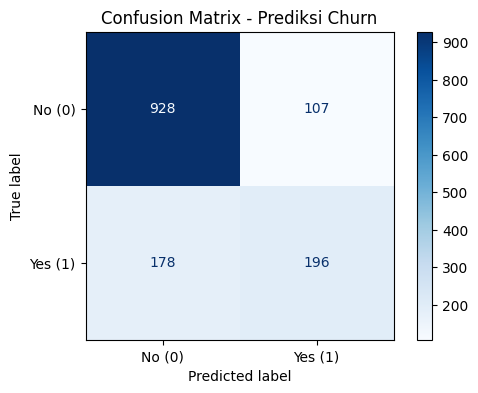

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
# TODO: Hitung prediksi dan probabilitas
y_pred = rf.predict(X_te)
y_pred_proba = rf.predict_proba(X_te)[:, 1]

# TODO: Tampilkan classification_report dan ROC-AUC
print("\n--- Evaluasi Model ---")
print("Classification Report:\n", classification_report(y_te, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_te, y_pred_proba))
# --- TAMBAHAN UNTUK CONFUSION MATRIX ---
print("\nConfusion Matrix (Angka):")
cm = confusion_matrix(y_te, y_pred)
print(cm)
# Membuat Visualisasi Heatmap Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No (0)', 'Yes (1)'])

fig, ax = plt.subplots(figsize=(6, 4))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix - Prediksi Churn')
plt.show()


Langkah 5: Prediksi Probabilitas dan Simpulkan

In [10]:
# TODO: Hitung probabilitas churn (predict_proba)
probabilitas_churn_pelanggan = rf.predict_proba(X_te)[:, 1]
print("\nContoh Prediksi Probabilitas Churn (7 Pelanggan Pertama di Data Uji):")
print(probabilitas_churn_pelanggan[:7])


Contoh Prediksi Probabilitas Churn (7 Pelanggan Pertama di Data Uji):
[0.00333333 0.63666667 0.07333333 0.37666667 0.01666667 0.56666667
 0.46333333]


Kesimpulan


1.   Mempelajari analisa dataset pelanggan (7.043 baris dan 21 kolom) yang memiliki tipe data yang bercampur (object, integer dan float)
2.   Metrik akurasi tidak cukup untuk data yang imbalanced, sebaiknya dilengkapi dengan precision, recall, F1 scoreaa dan ROC-AUC.
3. Nilai ROC-AUC mendekati 1 menunujukkan bahwa kemampuan model lebih baik dalam membedakan pelanggan yang churn atau tidak churn.
4. Memakai class_weight='balanced' terbukti dapat membantu ketidakseimbangan pada kelas
5. Prediksi probabilitas chrun dapat mengindentifikasi mana saja pelanggan yang beresiko tinggi sehingga perusahaan tersebut dapat memilih pelanggan yang berpotensi.